# Abundace table with kraken braken

We aim to explore shotgun from EMP biom data; for that goal we processed
Alberto Rafalli, Nelly Selem

Goals
   - [x] CReate a table with yeast fungi and other from shotgun
   - [x ] Search a visualization from shotgun

## Preparation

Install the latest version of scikit-bio if it hasn't been (needed for every Google Colab instance).

In [1]:
from importlib.util import find_spec

In [2]:
if find_spec('skbio') is None:
    !pip install -q scikit-bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 79.6 MB/s eta 0:00:00


In [3]:
import skbio
skbio.__version__

'0.7.1'

Import common libraries.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

If you use Google Colab, and would like to directly mount the shared Google Drive folder containing data files, please uncomment and execute the following code.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# # Specify your remote directory
HOME = '/content/drive/MyDrive/sci-kit-bio_local/Data/emp500'

If you use Google Colab or local Jupyter, and would like to download the data file package to the current directory, please uncomment and execute the following code.

If you use local Jupyter, and have already downloaded and extracted the data file package, please specify its directory.

In [7]:
# # Specify your local directory
#HOME = '/home/drz/Desktop/Data/emp500'

Check if the directory exists by listing its content.

In [8]:
!ls $HOME

amplicon  assembly  masspec  README.md	sample.tsv  shotgun


## The EMP500 study

A `README.md` file within the data directory provides basic information about the study. Take a quick look at it:

## Sample metadata

### Metadata table

The sample metadata table, `sample.tsv`, is a tab-separated values ([TSV](https://en.wikipedia.org/wiki/Tab-separated_values)) file with samples as rows and properties as columns. Let's take a peek at the table:

In [9]:
!head $HOME/sample.tsv | cut -c1-100

sample_name	sample_name_original	sample_type	collection_timestamp	country	depth_sample	description	e
13114.angenent.65.s001	Angenent65.misc.104	bioreactor sludge	08/09/2011 0:00	USA - New York	not appl
13114.angenent.65.s002	Angenent65.misc.519	bioreactor sludge	9/27/12 0:00	USA - New York	not applica
13114.angenent.65.s003	Angenent65.misc.946	bioreactor sludge	11/28/13 0:00	USA - New York	not applic
13114.angenent.65.s004	Angenent65.misc.1022	bioreactor sludge	02/12/2014 0:00	USA - New York	not app
13114.angenent.65.s005	Angenent65.misc.1538	bioreactor sludge	7/13/15 0:00	USA - New York	not applic
13114.angenent.65.s006	Angenent65.misc.1622	bioreactor sludge	10/05/2015 0:00	USA - New York	not app
13114.angenent.65.s007	Angenent65.misc.1722	bioreactor sludge	1/13/15 0:00	USA - New York	not applic
13114.angenent.65.s008	Angenent65.misc.1818	bioreactor sludge	4/18/16 0:00	USA - New York	not applic
13114.angenent.65.s009	Angenent65.misc.1888	bioreactor sludge	6/27/16 0:00	USA - New York	n

In [10]:
from skbio.metadata import SampleMetadata

In [11]:
meta = SampleMetadata.load(f'{HOME}/sample.tsv', default_missing_scheme='INSDC:missing')
#meta

A `SampleMetadata` object can be converted into a Pandas dataframe with:

In [12]:
df_meta = meta.to_dataframe()
df_meta.head(3)

,sample_name_original,sample_type,collection_timestamp,country,depth_sample,description,elevation,emp500_principal_investigator,emp500_study_id,emp500_pi_study_id,...,env_feature,env_material,env_package,geo_loc_name,host_subject_id,host_scientific_name,latitude,longitude,project_name,scientific_name
sample_name,,,,,,,,,,,,,,,,,,,,,
13114.angenent.65.s001,Angenent65.misc.104,bioreactor sludge,08/09/2011 0:00,USA - New York,NaN,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65.0,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.104,NaN,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome
13114.angenent.65.s002,Angenent65.misc.519,bioreactor sludge,9/27/12 0:00,USA - New York,NaN,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65.0,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.519,NaN,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome
13114.angenent.65.s003,Angenent65.misc.946,bioreactor sludge,11/28/13 0:00,USA - New York,NaN,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65.0,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.104,NaN,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome


In [13]:
# Get the shape of df_meta
df_meta_shape = df_meta.shape

# Print the shape
print(f"The shape of df_meta is: {df_meta_shape}")

The shape of df_meta is: (880, 33)


So there are metadata for 880 samples. In the next section we will filter to keep metadata only of those samples that have a minimal number of reads after quality control.

Here we can test metadata for selected samples.

In [14]:
# Select the row for the specific sample and the 'empo' columns
empo_data_for_sample = df_meta.loc['13114.rohwer.84.s012', ['empo_1', 'empo_2', 'empo_3']]

# Display the selected data
print("EMPO categories for sample 13114.zaneveld.9.s021:")
display(empo_data_for_sample)

EMPO categories for sample 13114.zaneveld.9.s021:


,13114.rohwer.84.s012
empo_1,Free-living
empo_2,Non-saline
empo_3,Water (non-saline)


## Shotgun sequencing kraken analysis

### Yeast Presence absence graph

This tsv already in github is the result of kraken-bracken analysis (alberto), plus test if every taxon isyeast or no (Elaine script)

In [15]:
# GitHub raw file URL
github_tsv_url = 'https://raw.githubusercontent.com/nselem/2025LitiVisit/refs/heads/main/code/07_kraken_absolute_isyeast_final.tsv'

# Load the TSV file into a pandas DataFrame
try:
    yeast_abundance_df = pd.read_csv(github_tsv_url, sep='\t')

    # Display the head of the DataFrame to verify
    display(yeast_abundance_df.head())

except Exception as e:
    print(f"An error occurred: {e}")
    print("Please ensure the GitHub link is correct and the file is accessible.")

print(f"Shape of the yeast_abundance_df: {yeast_abundance_df.shape}")
print(f"Number of samples: {yeast_abundance_df.shape[1]-10}")



,taxid,13114.angenent.65.s001,13114.angenent.65.s002,13114.angenent.65.s003,13114.angenent.65.s004,13114.angenent.65.s005,13114.angenent.65.s006,13114.angenent.65.s007,13114.angenent.65.s008,13114.angenent.65.s009,...,13114.zaneveld.9.s022,kingdom,phylum,class,order,family,genus,species,subphylum,isyeast
0,2036908,8922,0,0,0,0,0,101,0,0,...,0,NaN,Ascomycota,Leotiomycetes,Helotiales,Rutstroemiaceae,Clarireedia,jacksonii,Pezizomycotina,N
1,2860823,4241,0,0,0,231,0,0,0,0,...,0,NaN,Ascomycota,Leotiomycetes,Helotiales,Rutstroemiaceae,Clarireedia,paspali,Pezizomycotina,N
2,2867042,3223,0,0,0,0,0,0,0,0,...,0,NaN,Ascomycota,Leotiomycetes,Helotiales,Rutstroemiaceae,Clarireedia,hainanense,Pezizomycotina,N
3,2211668,473,0,0,0,0,0,0,0,0,...,0,NaN,Ascomycota,Leotiomycetes,Helotiales,Rutstroemiaceae,Clarireedia,monteithiana,Pezizomycotina,N
4,2086344,9845,0,0,0,0,0,0,0,0,...,0,NaN,Ascomycota,Leotiomycetes,Erysiphales,Erysiphaceae,Podosphaera,cerasi,Pezizomycotina,N


Shape of the yeast_abundance_df: (783, 760)
Number of samples: 750


In [16]:
#yeast_abundance_df[yeast_abundance_df['genus'] == 'Clarireedia']

### Filtering according to ITS sampling

In [17]:
## filter abundance columns of yeast_abundance_df by list ITS_SamplesMinReads100GenusMinPerc0.0.tsv
import pandas as pd

countITS=1000

# Ruta al archivo
sample_list_path = f"/content/drive/MyDrive/sci-kit-bio_local/FUNGI/tables/ITS_SamplesMinReads{countITS}filtered_sample_ids.txt"

# Leer líneas a una lista (removiendo saltos de línea)
with open(sample_list_path, 'r') as f:
    sample_ITS_ids = [line.strip() for line in f if line.strip()]

# Mostrar las primeras 10 muestras
print(sample_ITS_ids[:3])
print( "We vave samples of ",len(sample_ITS_ids),"ITS")

# Check which sample_ITS_ids are not in yeast_abundance_df columns BEFORE filtering
initial_yeast_cols = yeast_abundance_df.columns.tolist()
missing_samples = [sample_id for sample_id in sample_ITS_ids if sample_id not in initial_yeast_cols]
common_samples = [sample_id for sample_id in sample_ITS_ids if sample_id in initial_yeast_cols]
print("There are" , len(missing_samples), "that has ITS but not shotgun")

print(f"\nSample IDs from ITS list not found in initial yeast_abundance_df columns: {missing_samples}")
#sample_ITS_ids_common_columns=yeast_abundance_df.columns.isin(sample_ITS_ids)

taxonomy_cols = ['kingdom','phylum','class','order','family','genus','species','subphylum','isyeast']
print( "The kraken matrix contain ",len(sample_ITS_ids)-10,"samples")

print("Then should be" , len(sample_ITS_ids)-len(missing_samples), "samples in common","=",len(common_samples),"common samples")

# Si tu primera columna se llama 'taxid', simplemente defínela como lista
firstcolum = ['taxid']

# Combinar columnas válidas: las que están en el dataframe o son columnas de taxonomía
valid_columns = firstcolum + sample_ITS_ids + taxonomy_cols
# Filtrar el dataframe conservando solo esas columnas
yeast_abundance_filtered_ITS = pd.DataFrame()
#yeast_abundance_filtered_ITS['taxid']= yeast_abundance_df['taxid']
yeast_abundance_filtered_ITS = yeast_abundance_df.loc[:, yeast_abundance_df.columns.isin(valid_columns)]

# 3️Mostrar resumen
print(f"Total of conserved columns: {yeast_abundance_filtered_ITS.shape[1]-10}")
print("Example of conserved columns:", yeast_abundance_filtered_ITS.columns[:5].tolist())

#(Opcional) Ver las primeras filas del resultado
yeast_abundance_df = pd.DataFrame()
yeast_abundance_df=yeast_abundance_filtered_ITS
yeast_abundance_df.head()


['13114.bowen.74.s003', '13114.girguis.50.s003', '13114.girguis.50.s007']
We vave samples of  125 ITS
There are 0 that has ITS but not shotgun

Sample IDs from ITS list not found in initial yeast_abundance_df columns: []
The kraken matrix contain  115 samples
Then should be 125 samples in common = 125 common samples
Total of conserved columns: 125
Example of conserved columns: ['taxid', '13114.bowen.74.s003', '13114.girguis.50.s003', '13114.girguis.50.s007', '13114.girguis.50.s009']


,taxid,13114.bowen.74.s003,13114.girguis.50.s003,13114.girguis.50.s007,13114.girguis.50.s009,13114.jensen.43.s006,13114.jensen.43.s016,13114.king.27.s001,13114.king.27.s005,13114.king.27.s010,...,13114.zaneveld.9.s020,kingdom,phylum,class,order,family,genus,species,subphylum,isyeast
0,2036908,0,0,0,0,0,0,0,0,0,...,18631,NaN,Ascomycota,Leotiomycetes,Helotiales,Rutstroemiaceae,Clarireedia,jacksonii,Pezizomycotina,N
1,2860823,0,0,0,0,0,0,0,0,0,...,0,NaN,Ascomycota,Leotiomycetes,Helotiales,Rutstroemiaceae,Clarireedia,paspali,Pezizomycotina,N
2,2867042,0,0,0,0,0,0,0,0,0,...,2525,NaN,Ascomycota,Leotiomycetes,Helotiales,Rutstroemiaceae,Clarireedia,hainanense,Pezizomycotina,N
3,2211668,0,0,0,0,0,0,0,0,0,...,5791,NaN,Ascomycota,Leotiomycetes,Helotiales,Rutstroemiaceae,Clarireedia,monteithiana,Pezizomycotina,N
4,2086344,0,0,0,0,0,0,0,0,0,...,0,NaN,Ascomycota,Leotiomycetes,Erysiphales,Erysiphaceae,Podosphaera,cerasi,Pezizomycotina,N


### Getting count table

In [18]:
# Cuenta los valores únicos en la columna 'isyeast'
print(yeast_abundance_df['isyeast'].value_counts())


isyeast
N    658
Y    125
Name: count, dtype: int64


How many tax ids do we have that are yeast?

In [19]:
# Filter the DataFrame to keep only rows where 'isyeast' is 'Y'
yeast_only_df = yeast_abundance_df[yeast_abundance_df['isyeast'] == 'Y']
# Count the number of rows in the filtered DataFrame
num_yeast_taxids = len(yeast_only_df) # Print the count
print(f"Number of tax IDs with 'isyeast' as 'Y': {num_yeast_taxids}")
#yeast_only_df.head(5)

# Assuming abundance columns are all columns except taxonomic ones and 'taxid'
columns_to_exclude = ['taxid', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'subphylum', 'taxa', 'result', 'isyeast']
abundance_columns = yeast_abundance_df.columns.difference(columns_to_exclude)

# Check for each sample if at least one abundance value is greater than zero
samples_with_any_abundance = (yeast_abundance_df[abundance_columns] > 0).any(axis=0)
# Count the number of samples where this condition is True
total_samples_with_any_fungal_abundance_in_data_df = samples_with_any_abundance.sum()

# Check for each sample if at least one abundance value is greater than zero
samples_with_any_yeast_abundance = (yeast_only_df[abundance_columns] > 0).any(axis=0)
# Count the number of samples where this condition is True
total_samples_with_any_yeast_abundance_in_data_df = samples_with_any_yeast_abundance.sum()

# Print the result
print(f"Total number of samples with any fungal abundance (at least one taxid greater than zero) in original dataframe: {total_samples_with_any_fungal_abundance_in_data_df}")
# Print the result
print(f"Total number of samples with any yeast abundance (at least one taxid greater than zero) in original dataframe: {total_samples_with_any_yeast_abundance_in_data_df}")

Number of tax IDs with 'isyeast' as 'Y': 125
Total number of samples with any fungal abundance (at least one taxid greater than zero) in original dataframe: 109
Total number of samples with any yeast abundance (at least one taxid greater than zero) in original dataframe: 51


Verify that all 750 samples has metadata

In [20]:
# Identify columns to exclude (taxid and taxonomic columns)
columns_to_exclude = ['taxid', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'subphylum', 'taxa', 'result', 'isyeast']

# Get the list of all columns in yeast_abundance_df
all_columns = yeast_abundance_df.columns.tolist()

# Filter to keep only the sample columns
sample_columns_list = [col for col in all_columns if col not in columns_to_exclude]

# Filter df_meta to keep only samples present in the sample_columns_list
filtered_df_meta = df_meta.loc[df_meta.index.intersection(sample_columns_list)]

# Display the shape of the filtered df_meta and its head to verify
print(f"Shape of filtered df_meta: {filtered_df_meta.shape}")
display(filtered_df_meta.head())

Shape of filtered df_meta: (125, 33)


,sample_name_original,sample_type,collection_timestamp,country,depth_sample,description,elevation,emp500_principal_investigator,emp500_study_id,emp500_pi_study_id,...,env_feature,env_material,env_package,geo_loc_name,host_subject_id,host_scientific_name,latitude,longitude,project_name,scientific_name
sample_name,,,,,,,,,,,,,,,,,,,,,
13114.bowen.74.s003,Bowen74.sed3,sediment,5/15/14 0:00,USA - Massachusetts,0,Salt marsh sediment sample collected from the ...,0.0,Bowen,74.0,Bowen74,...,marine benthic feature,marine sediment,sediment,United States of America:Commonwealth of Massa...,Bowen74.sed3,NaN,42.739897,-70.83609,Plum Island sediments,sediment metagenome
13114.girguis.50.s003,Girguis50.FinBP3,stool,05/07/2015 0:00,USA - Massachusetts,NaN,Fin whale feces (from individual BP3),0.0,Girguis,50.0,Girguis50,...,animal-associated habitat,feces,host-associated,United States of America:Commonwealth of Massa...,FinBP3,Balaenoptera physalus,41.680000,-70.20000,50-GirguisEMPWhales,gut metagenome
13114.girguis.50.s007,Girguis50.HumpbackAK3,stool,11/15/09 0:00,USA - Alaska,NaN,Humpback whale feces (from individual AK3),0.0,Girguis,50.0,Girguis50,...,animal-associated habitat,feces,host-associated,United States of America:State of Alaska:Seymo...,HumpbackAK3,Megaptera novaeangliae,57.600000,-133.90000,50-GirguisEMPWhales,gut metagenome
13114.girguis.50.s009,Girguis50.RightEG3,stool,9/17/08 0:00,Canada,NaN,Right whale feces (from individual EG3),0.0,Girguis,50.0,Girguis50,...,animal-associated habitat,feces,host-associated,Canada:Nova Scotia:Bay of Fundy,RightEG3,Eubalaena glacialis,44.667000,-66.19300,50-GirguisEMPWhales,gut metagenome
13114.jensen.43.s006,Jensen43.BZ15.16,sediment,09/06/2015,Belize,6,Jensen43.sediment.7,0.0,Jensen,43.0,Jensen43,...,lagoon,marine sediment,sediment,Atlantic Ocean:Northwest Atlantic Ocean:Belize,BZ15-16,NaN,16.795560,-88.12250,Jensen sediments from global ocean,marine sediment metagenome


See the number of samples by category empo 3

In [21]:
# Generate a table of sample counts for each empo_3 category
empo3_counts = filtered_df_meta['empo_3'].value_counts()

# Display the resulting table
print("Number of samples per EMPO 3 category (from filtered_df_meta):")
display(empo3_counts)

# Calculate and display the total number of samples
total_samples = empo3_counts.sum()
print(f"\nTotal number of filtered samples: {total_samples}")

Number of samples per EMPO 3 category (from filtered_df_meta):


,count
empo_3,
Animal distal gut,37
Plant corpus,21
Soil (non-saline),19
Sediment (non-saline),12
Animal secretion,11
Fungus corpus,7
Sediment (saline),5
Animal corpus,4
Water (saline),3



Total number of filtered samples: 125


Then we have 750 samples, and 750 metadata.

In [22]:
# Filter the DataFrame to keep only rows where 'isyeast' is 'Y'
yeast_abundance_yeast_only =   yeast_abundance_df[
      yeast_abundance_df['isyeast'] == 'Y'
]

# Set 'taxid' as the index
yeast_abundance_yeast_only = yeast_abundance_yeast_only.set_index('taxid')

# Asegurar que todo sea numérico, NaN se convierten en 0
df_coerce = yeast_abundance_yeast_only.apply(pd.to_numeric, errors="coerce").fillna(0)
df_coerce_fungus = yeast_abundance_df.apply(pd.to_numeric, errors="coerce").fillna(0)

# Elimina todas las columnas desde 'kingdom' en adelante
# Now that taxid is the index, we can drop the taxonomic columns by name if they are still present as columns
taxonomy_columns_to_drop = ['kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'subphylum', 'taxa', 'result', 'isyeast']
# Filter out columns that don't exist in the DataFrame before dropping
columns_to_drop_exist = [col for col in taxonomy_columns_to_drop if col in df_coerce.columns]
columns_to_drop_exist_fungus = [col for col in taxonomy_columns_to_drop if col in df_coerce_fungus.columns]


df_clean = df_coerce.drop(columns=columns_to_drop_exist, errors='ignore')
Fungus_abundance_df_clean=df_coerce_fungus.drop(columns=columns_to_drop_exist_fungus, errors='ignore')
Fungus_abundance_df_clean= Fungus_abundance_df_clean.set_index('taxid')


print(f"Shape of the DataFrame df_clean: {df_clean.shape}")
df_clean.head(5)

print(f"Shape of the Fungus_abundance_df_clean: {Fungus_abundance_df_clean.shape}")
#Fungus_abundance_df_clean.head(5)
#df_clean.head(5)


Shape of the DataFrame df_clean: (125, 125)
Shape of the Fungus_abundance_df_clean: (783, 125)


We have 125 yeast tax ids and 783 fungal taxid

In [23]:
# Calculate fungusPresence (same logic as any_gt0): 1 if any value in a sample is > 0, 0 otherwise
# Using df_clean which contains cleaned absolute abundances of yeast taxa
presence_status = (df_clean > 0).any(axis=0).astype(int)

# Calculate fungusPresence for the entire fungus data
presence_status2 = (Fungus_abundance_df_clean > 0).any(axis=0).astype(int)


# Create a DataFrame with both columns
presence_df = pd.DataFrame({
    'any_gt0': presence_status,
    'ContainFungus': presence_status2
})

# Calculate 'OnlyFungus' using XOR: 1 if any_gt0 is different from ContainFungus
# Since any_gt0 is a subset of ContainFungus (yeasts are fungi), XOR will be 1 only when any_gt0=0 and ContainFungus=1
presence_df['OnlyFungus'] = (presence_df['any_gt0'] ^ presence_df['ContainFungus'])


# Display the head of the new DataFrame with the new column
print("DataFrame with any_gt0, ContainFungus, and OnlyFungus columns:")
display(presence_df.head(10))

# Print the total count of 1s in each column
print(f"\nTotal samples with yeast= 1: {presence_df['any_gt0'].sum()}")
print(f"Total samples with ContainFungus = 1: {presence_df['ContainFungus'].sum()}")
print(f"Total samples with OnlyFungus = 1: {presence_df['OnlyFungus'].sum()}")

DataFrame with any_gt0, ContainFungus, and OnlyFungus columns:


,any_gt0,ContainFungus,OnlyFungus
13114.bowen.74.s003,0,1,1
13114.girguis.50.s003,0,1,1
13114.girguis.50.s007,0,1,1
13114.girguis.50.s009,1,1,0
13114.jensen.43.s006,0,0,0
13114.jensen.43.s016,0,0,0
13114.king.27.s001,0,1,1
13114.king.27.s005,0,1,1
13114.king.27.s010,1,1,0
13114.king.27.s016,0,1,1



Total samples with yeast= 1: 51
Total samples with ContainFungus = 1: 109
Total samples with OnlyFungus = 1: 58


In [24]:
# Transpose new_df so samples are rows
new_df_T = presence_df

# Merge the transposed new_df with the sample metadata df_meta
# Merge on the index (sample names)
merged_new_df = new_df_T.merge(df_meta[['empo_3']], left_index=True, right_index=True, how='left')
merged_new_df.head()
# Ensure presence_df is available from cell sz-01sxRl29o

# Merge merged_new_df with ContainFungus and OnlyFungus from presence_df
#merged_new_df = merged_new_df.merge(presence_df[['ContainFungus', 'OnlyFungus']], left_index=True, right_index=True, how='left')

,any_gt0,ContainFungus,OnlyFungus,empo_3
13114.bowen.74.s003,0,1,1,Sediment (saline)
13114.girguis.50.s003,0,1,1,Animal distal gut
13114.girguis.50.s007,0,1,1,Animal distal gut
13114.girguis.50.s009,1,1,0,Animal distal gut
13114.jensen.43.s006,0,0,0,Sediment (saline)


In [25]:


# Add a column 'Nofungal Negative' which is the inverse of ContainFungus
merged_new_df['Nofungal'] = 1 - merged_new_df['ContainFungus']


# Display the head of the merged DataFrame
print("Merged DataFrame with yeast presence, EMPO 3, ContainFungus, OnlyFungus, and Nofungal:")
display(merged_new_df.head(10))
#merged_new_df

Merged DataFrame with yeast presence, EMPO 3, ContainFungus, OnlyFungus, and Nofungal:


,any_gt0,ContainFungus,OnlyFungus,empo_3,Nofungal
13114.bowen.74.s003,0,1,1,Sediment (saline),0
13114.girguis.50.s003,0,1,1,Animal distal gut,0
13114.girguis.50.s007,0,1,1,Animal distal gut,0
13114.girguis.50.s009,1,1,0,Animal distal gut,0
13114.jensen.43.s006,0,0,0,Sediment (saline),1
13114.jensen.43.s016,0,0,0,Sediment (saline),1
13114.king.27.s001,0,1,1,Soil (non-saline),0
13114.king.27.s005,0,1,1,Soil (non-saline),0
13114.king.27.s010,1,1,0,Soil (non-saline),0
13114.king.27.s016,0,1,1,Soil (non-saline),0


Lets calculate how many samples have yests vs how many does not and how many contain fungus

In [26]:
# Group merged_new_df by empo_3 and calculate the sum of 1s for the specified columns
count_table_subset = merged_new_df.groupby('empo_3')[['any_gt0', 'OnlyFungus', 'Nofungal']].sum()

# Rename columns for clarity (optional)
count_table_subset = count_table_subset.rename(columns={
    'any_gt0': 'Samples with Yeast',
    'OnlyFungus': 'Samples with Only Fungus',
    'Nofungal Negative': 'Samples without Fungus'
})

# Calculate the total number of samples per empo_3 category
# This can be done by counting the number of samples in merged_new_df per empo_3
total_samples_per_empo3 = merged_new_df.groupby('empo_3').size().rename('Total Samples')

# Add the 'Total Samples' column to the count_table_subset
count_table_subset = count_table_subset.merge(total_samples_per_empo3, left_index=True, right_index=True, how='left')


# Display the resulting table
print("Sample Counts for Yeast, Only Fungus, and No Fungus per EMPO 3 Category:")
display(count_table_subset)

# Calculate and display the overall total number of samples
overall_total_samples = count_table_subset['Total Samples'].sum()
print(f"\nOverall total number of samples: {overall_total_samples}")

Sample Counts for Yeast, Only Fungus, and No Fungus per EMPO 3 Category:


,Samples with Yeast,Samples with Only Fungus,Nofungal,Total Samples
empo_3,,,,
Animal corpus,2,2,0,4
Animal distal gut,24,8,5,37
Animal proximal gut,1,0,1,2
Animal secretion,0,8,3,11
Fungus corpus,1,6,0,7
Plant corpus,9,12,0,21
Plant surface,0,1,1,2
Sediment (non-saline),5,5,2,12
Sediment (saline),2,1,2,5



Overall total number of samples: 125


Saving this table to join with the others


In [27]:
# # Define the output file path
HOME = '/content/drive/MyDrive/sci-kit-bio_local/FUNGI/'
output_file_path = f'{HOME}/tables/07_Kraken_{countITS}ReadsITS_grouped_counts.tsv'

# # Print the merged_df DataFrame to a CSV file
count_table_subset.to_csv(output_file_path,sep='\t', index=True)

In [28]:
# Calculate relative abundance for each count column
count_table_subset_ra_calculated = count_table_subset.copy()

# Divide each column by the 'Total Samples' column to get relative abundance
for col in ['Samples with Yeast', 'Samples with Only Fungus', 'Nofungal']:
    count_table_subset_ra_calculated[f'{col} (RA)'] = count_table_subset_ra_calculated[col] / count_table_subset_ra_calculated['Total Samples']

# Display the resulting table with relative abundances
print("Relative Abundance of Sample Types per EMPO 3 Category:")
display(count_table_subset_ra_calculated)

Relative Abundance of Sample Types per EMPO 3 Category:


,Samples with Yeast,Samples with Only Fungus,Nofungal,Total Samples,Samples with Yeast (RA),Samples with Only Fungus (RA),Nofungal (RA)
empo_3,,,,,,,
Animal corpus,2,2,0,4,0.500000,0.500000,0.000000
Animal distal gut,24,8,5,37,0.648649,0.216216,0.135135
Animal proximal gut,1,0,1,2,0.500000,0.000000,0.500000
Animal secretion,0,8,3,11,0.000000,0.727273,0.272727
Fungus corpus,1,6,0,7,0.142857,0.857143,0.000000
Plant corpus,9,12,0,21,0.428571,0.571429,0.000000
Plant surface,0,1,1,2,0.000000,0.500000,0.500000
Sediment (non-saline),5,5,2,12,0.416667,0.416667,0.166667
Sediment (saline),2,1,2,5,0.400000,0.200000,0.400000


In [29]:
# Create a new DataFrame with only the relative abundance columns
count_table_subset_ra = count_table_subset_ra_calculated[['Samples with Yeast (RA)', 'Samples with Only Fungus (RA)', 'Nofungal (RA)']]

# Display the new DataFrame
print("Table with only Relative Abundance values:")
display(count_table_subset_ra)

Table with only Relative Abundance values:


,Samples with Yeast (RA),Samples with Only Fungus (RA),Nofungal (RA)
empo_3,,,
Animal corpus,0.500000,0.500000,0.000000
Animal distal gut,0.648649,0.216216,0.135135
Animal proximal gut,0.500000,0.000000,0.500000
Animal secretion,0.000000,0.727273,0.272727
Fungus corpus,0.142857,0.857143,0.000000
Plant corpus,0.428571,0.571429,0.000000
Plant surface,0.000000,0.500000,0.500000
Sediment (non-saline),0.416667,0.416667,0.166667
Sediment (saline),0.400000,0.200000,0.400000


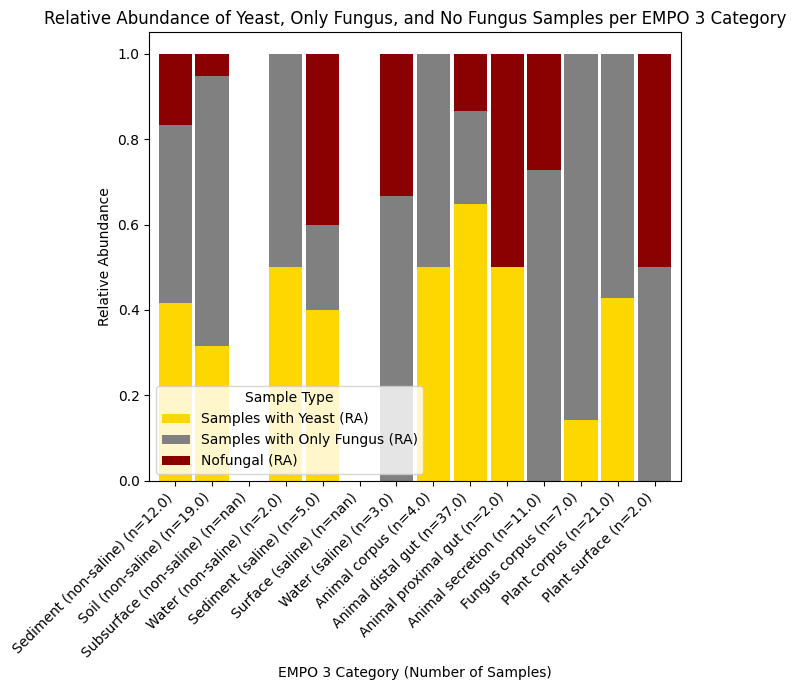

In [30]:
# Define the desired order for EMPO 3 categories
empo_3_order = ['Sediment (non-saline)','Soil (non-saline)', 'Subsurface (non-saline)','Water (non-saline)','Sediment (saline)','Surface (saline)','Water (saline)', 'Animal corpus', 'Animal distal gut', 'Animal proximal gut',  'Animal secretion', 'Fungus corpus', 'Plant corpus', 'Plant surface']

# Reindex the DataFrame according to the desired order
count_table_subset_ra_ordered = count_table_subset_ra.reindex(empo_3_order)

# Get the total sample counts from the absolute abundance table and reindex
total_samples_ordered = count_table_subset['Total Samples'].reindex(empo_3_order)

# Create new labels with the number of samples
new_labels = [f'{cat} (n={total_samples_ordered[cat]})' for cat in empo_3_order]

# Plot a stacked bar chart using the ordered relative abundance table
columns_to_plot_ra = ['Samples with Yeast (RA)', 'Samples with Only Fungus (RA)', 'Nofungal (RA)']
ax_ra_plot = count_table_subset_ra_ordered[columns_to_plot_ra].plot(kind='bar', stacked=True, figsize=(7, 7), color=['gold', 'gray', 'darkred'], width=0.9)

# Set the new labels for the x-axis
ax_ra_plot.set_xticklabels(new_labels)

# Add titles and labels
plt.title('Relative Abundance of Yeast, Only Fungus, and No Fungus Samples per EMPO 3 Category')
plt.xlabel('EMPO 3 Category (Number of Samples)')
plt.ylabel('Relative Abundance')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability

# Add legend
plt.legend(title='Sample Type')

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Show the plot
plt.show()

In [31]:
# Define the output file path
HOME = '/content/drive/MyDrive/sci-kit-bio_local/FUNGI/'
output_file_path = f'{HOME}/tables/relative_abundance_empo3_stacked_bar_plot.svg'

# Save the plot as an SVG file
plt.savefig(output_file_path, format='svg')

# Show the plot after saving
plt.show()

<Figure size 640x480 with 0 Axes>